In [5]:
from dotenv import load_dotenv

load_dotenv()

True

In [1]:
from typing import TypedDict  
  
class AgentState(TypedDict):  
    task: str  
    result: str

In [6]:
from langchain_openai import ChatOpenAI  
  
llm = ChatOpenAI(model="gpt-4o-mini")  
  
def think(state: AgentState):  
    response = llm.invoke(f"Solve this task: {state['task']}")  
    return {"result": response.content}

In [7]:
from langgraph.graph import StateGraph  
  
builder = StateGraph(AgentState)  
  
builder.add_node("think", think)  
builder.set_entry_point("think")  
  
graph = builder.compile()

In [8]:
result = graph.invoke({"task": "Write a Python function to reverse a list"})  
print(result)

{'task': 'Write a Python function to reverse a list', 'result': "Certainly! To reverse a list in Python, you can create a function that takes a list as an argument and returns a new list that is the reverse of the original. Here's a simple implementation of such a function:\n\n```python\ndef reverse_list(input_list):\n    # Return a new list that is the reverse of the input list\n    return input_list[::-1]\n\n# Example of using the function\nexample_list = [1, 2, 3, 4, 5]\nreversed_list = reverse_list(example_list)\nprint(reversed_list)  # Output: [5, 4, 3, 2, 1]\n```\n\n### Explanation:\n- The function `reverse_list` takes a single argument `input_list`.\n- The slicing method `input_list[::-1]` creates a new list that contains the elements of `input_list` in reverse order.\n- The function returns this reversed list.\n\nYou can also reverse a list in place by modifying the original list directly, if that's what you're looking for:\n\n```python\ndef reverse_list_in_place(input_list):\n

In [9]:
def review(state: AgentState):  
    feedback = llm.invoke(f"Review this result: {state['result']}")  
    return {"result": feedback.content}

In [10]:
builder.add_node("review", review)  
builder.add_edge("think", "review")

Adding a node to a graph that has already been compiled. This will not be reflected in the compiled graph.
Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.


In [11]:
def calculator(expression: str) -> str:  
    return str(eval(expression))

In [12]:
def use_tool(state: AgentState):  
    if "calculate" in state["task"]:  
        result = calculator("2+2")  
        return {"result": result}  
    return state

In [13]:
builder.add_node("tool", use_tool)  
builder.add_edge("think", "tool")

Adding a node to a graph that has already been compiled. This will not be reflected in the compiled graph.
Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.


In [14]:
def should_continue(state: AgentState):  
    if "improve" in state["result"]:  
        return "think"  
    return "end"  
  
builder.add_conditional_edges(  
    "review",  
    should_continue,  
    {  
        "think": "think",  
        "end": "__end__"  
    }  
)

Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.


In [19]:
graph = builder.compile()

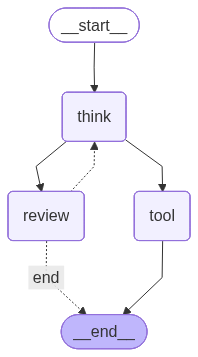

In [20]:
# view graph
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))